In [1]:
%matplotlib inline

In [2]:
import string
import torch
import torch.nn as nn
from data import Dataloader
from utils import helper
from model import RNN
from train import Trainer
import matplotlib.pyplot as plt

if __name__ == '__main__':
    dataloader = Dataloader()
    category_lines, all_category = dataloader.load_data()
    hidden_size = 256
    output_size = len(dataloader.all_categories)
    model = RNN(dataloader.N_LETTERS, hidden_size, output_size)
    criterion = nn.NLLLoss()
    learning_rate = 0.005
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    
    trainer = Trainer(model, dataloader, optimizer, criterion)
    all_losses = trainer.train_model(plot=False)

    while True:
        sentence = input('Input: ')
        if sentence == ':quit':
            break
        trainer.predict(sentence)


5000 (5.00%) 2.5492 / Webster → German (WRONG (English))
10000 (10.00%) 1.0774 / Schermer → German (CORRECT)
15000 (15.00%) 0.7657 / Xian → Chinese (CORRECT)
20000 (20.00%) 0.0521 / Kaloxylos → Greek (CORRECT)
25000 (25.00%) 1.5496 / Sherak → Arabic (WRONG (Czech))
30000 (30.00%) 0.9716 / Rome → French (CORRECT)
35000 (35.00%) 0.0874 / Marchioni → Italian (CORRECT)
40000 (40.00%) 3.6681 / Wiater → German (WRONG (Polish))
45000 (45.00%) 4.0674 / Fairbrother → Dutch (WRONG (English))
50000 (50.00%) 0.0742 / Tieu → Vietnamese (CORRECT)
55000 (55.00%) 0.0072 / Iwahara → Japanese (CORRECT)
60000 (60.00%) 0.5291 / Kieu → Vietnamese (CORRECT)
65000 (65.00%) 0.6749 / Murray → Scottish (CORRECT)
70000 (70.00%) 3.1317 / Oliver → Spanish (WRONG (English))
75000 (75.00%) 1.3282 / Dresdner → English (WRONG (German))
80000 (80.00%) 0.0107 / Molokov → Russian (CORRECT)
85000 (85.00%) 2.8728 / Hung → German (WRONG (Korean))
90000 (90.00%) 2.0728 / Munro → Spanish (WRONG (Scottish))
95000 (95.00%) 0.09

In [3]:
print(all_losses)

[2.8481, 2.716, 2.4793, 2.3136, 2.1241, 2.0907, 2.0309, 1.9273, 1.8906, 1.8602, 1.7676, 1.7227, 1.746, 1.6334, 1.6621, 1.6403, 1.5892, 1.6406, 1.5348, 1.5457, 1.5461, 1.4886, 1.5675, 1.482, 1.5109, 1.443, 1.4631, 1.4064, 1.4289, 1.3921, 1.3839, 1.4328, 1.3311, 1.3828, 1.4128, 1.3732, 1.3915, 1.3116, 1.3357, 1.3529, 1.3926, 1.2936, 1.37, 1.3555, 1.2769, 1.2885, 1.3215, 1.3554, 1.3179, 1.1956, 1.2818, 1.1851, 1.2831, 1.2446, 1.28, 1.2072, 1.2067, 1.2426, 1.199, 1.1911, 1.2005, 1.2076, 1.2033, 1.1282, 1.1629, 1.146, 1.2069, 1.1263, 1.1445, 1.1084, 1.1622, 1.1347, 1.1232, 1.1581, 1.0623, 1.0991, 1.0779, 1.0609, 1.0352, 1.0975, 1.0876, 1.0672, 1.0676, 1.0651, 1.0236, 1.0111, 0.9591, 0.9915, 1.0066, 0.9163, 1.0132, 0.9988, 0.9516, 0.8441, 0.9496, 0.9371, 0.9128, 0.9289, 0.9394, 0.9319]


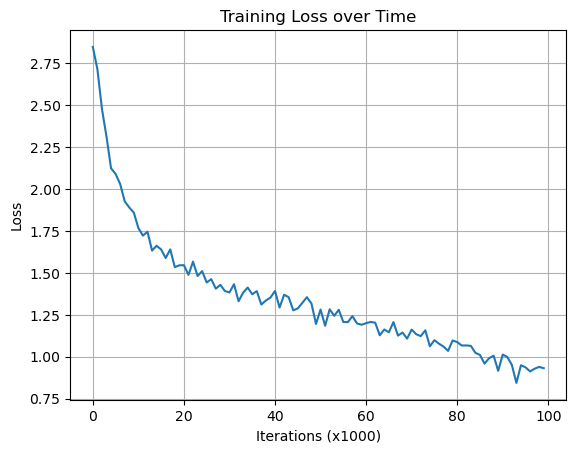

In [4]:
import matplotlib.pyplot as plt

plt.plot(all_losses)
plt.xlabel('Iterations (x1000)')
plt.ylabel('Loss')
plt.title('Training Loss over Time')
plt.grid(True)
plt.show()


In [5]:
plt.savefig("training_loss.png")


<Figure size 640x480 with 0 Axes>